In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("netflix_titles.csv")

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (8807, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

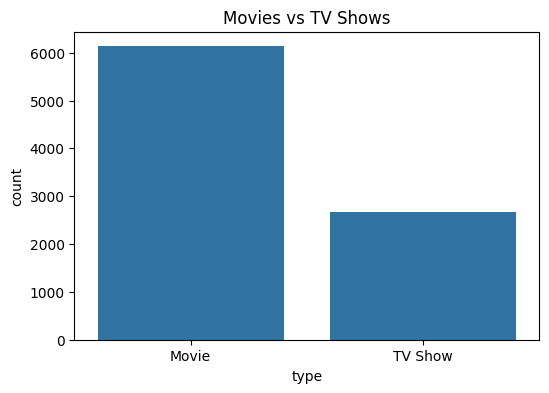

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

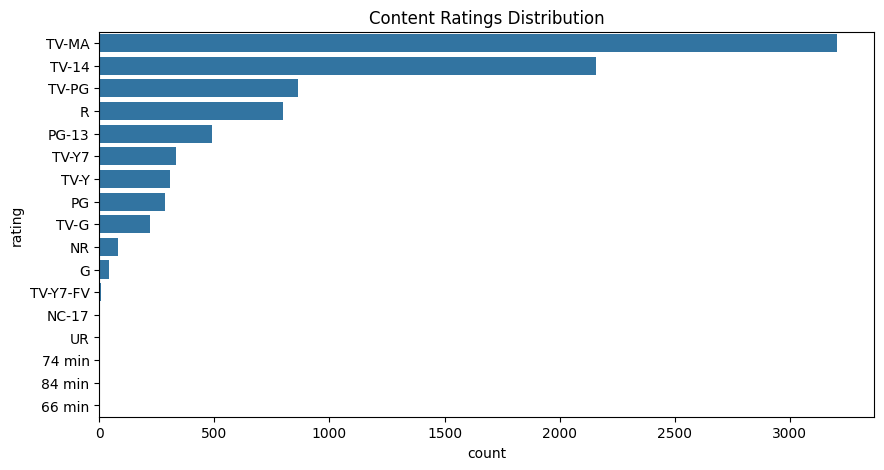

In [8]:
plt.figure(figsize=(10,5))
sns.countplot(y='rating',
              data=df,
              order=df['rating'].value_counts().index)

plt.title("Content Ratings Distribution")
plt.show()

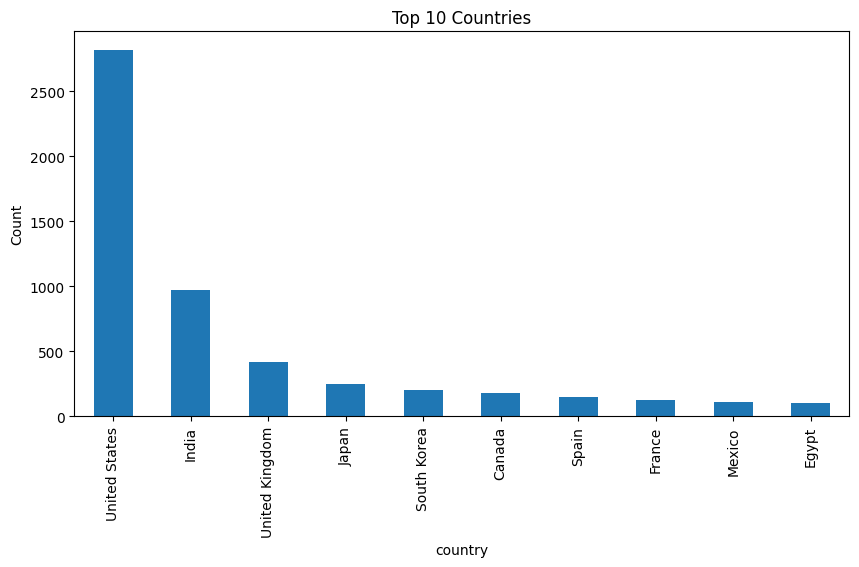

In [9]:
plt.figure(figsize=(10,5))

df['country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries")
plt.ylabel("Count")
plt.show()

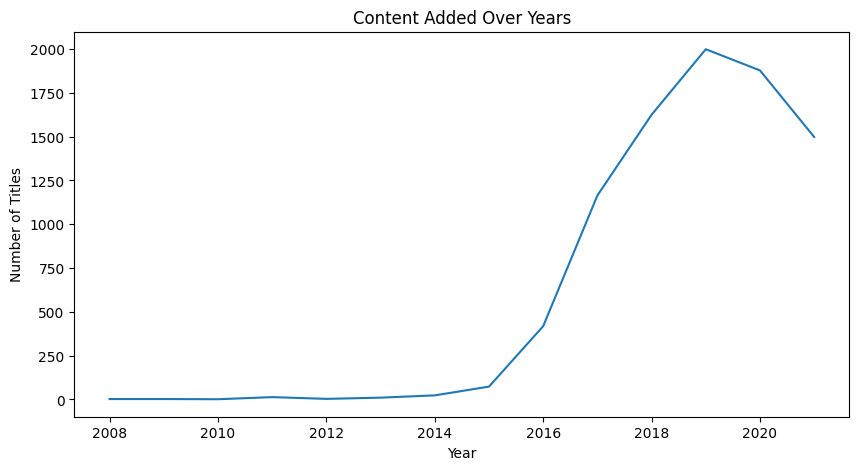

In [10]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year

plt.figure(figsize=(10,5))

df['year_added'].value_counts().sort_index().plot()

plt.title("Content Added Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

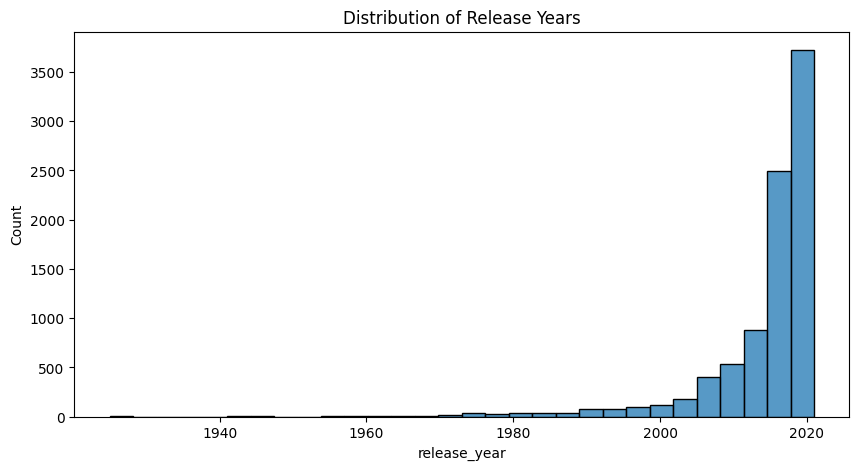

In [11]:
plt.figure(figsize=(10,5))

sns.histplot(df['release_year'], bins=30)

plt.title("Distribution of Release Years")
plt.show()

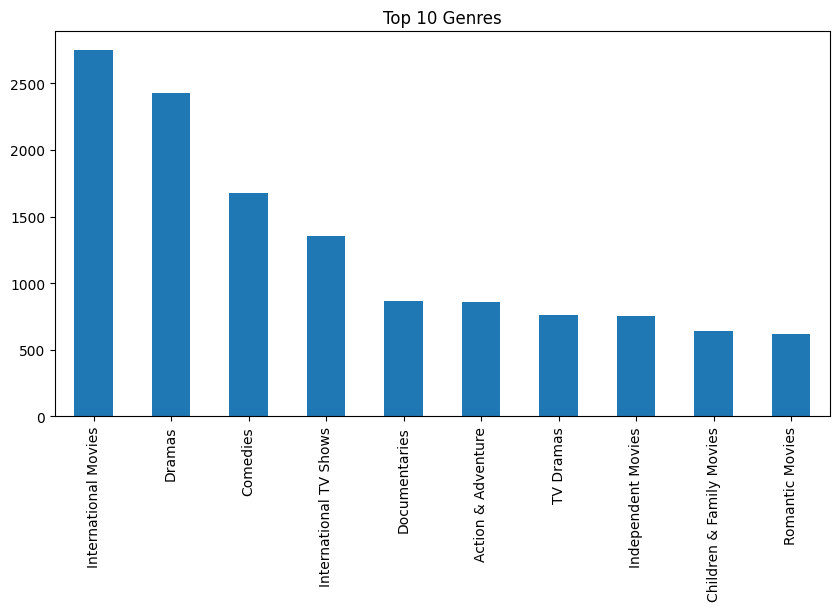

In [12]:
genres = df['listed_in'].str.split(', ', expand=True).stack()

plt.figure(figsize=(10,5))

genres.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")
plt.show()

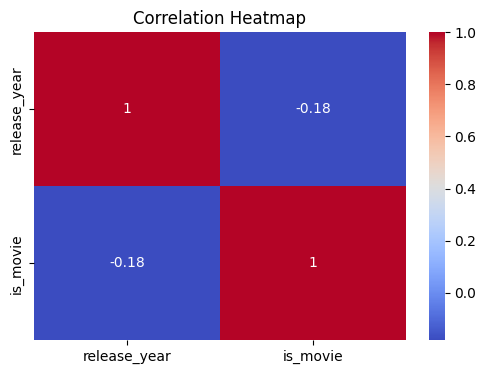

In [13]:
df['is_movie'] = df['type'].map({
    'Movie':1,
    'TV Show':0
})

numeric_df = df[['release_year','is_movie']]

plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

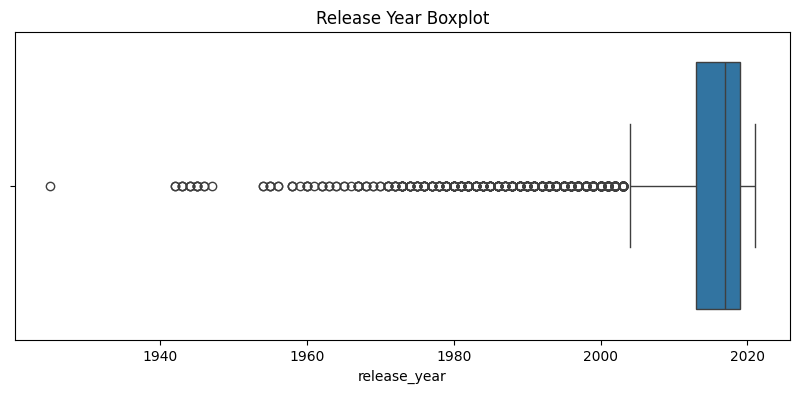

In [14]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df['release_year'])

plt.title("Release Year Boxplot")
plt.show()

# Summary of Findings

1. Movies significantly outnumber TV Shows.
2. TV-MA and TV-14 are the dominant ratings.
3. The United States produces the highest amount of content.
4. Netflix content additions increased rapidly after 2015.
5. Most titles are from recent years.
6. Drama and International Movies are among the most popular genres.
7. Several fields contain missing values that may require preprocessing.